In [1]:
import os
print(os.getcwd())
cwd = os.getcwd()
os.chdir('../../')
import rsnapsim as rsnp  # import the rsnapsim
os.chdir(cwd)

import numpy as np
import matplotlib.pyplot as plt

C:\Users\willi\Documents\GitHub\rSNAPsim\rsnapsim\interactive_notebooks
['C:\\Users\\willi\\anaconda3\\envs\\py312\\Library\\include\\', 'C:\\Users\\willi\\anaconda3\\envs\\py312\\Library\\include\\']
eigen instillation found...
['C:\\Users\\willi\\anaconda3\\envs\\py312\\Library\\include\\', 'C:\\Users\\willi\\anaconda3\\envs\\py312\\Library\\include\\']
['C:\\Users\\willi\\anaconda3\\envs\\py312\\Library\\include\\', 'C:\\Users\\willi\\anaconda3\\envs\\py312\\Library\\include\\']


In [2]:

example_mRNA = '''ATGGCGAACCTTGGCTGCTGGATGCTGGTTCTCTTTGTGGCCACATGGAGTGACCTGGGC
                    CTCTGCAAGAAGCGCCCGAAGCCTGGAGGATGGAACACTGGGGGCAGCCGATACCCGGGG
                    CAGGGCAGCCCTGGAGGCAACCGCTACCCACCTCAGGGCGGTGGTGGCTGGGGGCAGCCT
                    CATGGTGGTGGCTGGGGGCAGCCTCATGGTGGTGGCTGGGGGCAGCCCCATGGTGGTGGC
                    TGGGGACAGCCTCATGGTGGTGGCTGGGGTCAAGGAGGTGGCACCCACAGTCAGTGGAAC
                    AAGCCGAGTAAGCCAAAAACCAACATGAAGCACATGGCTGGTGCTGCAGCAGCTGGGGCA
                    GTGGTGGGGGGCCTTGGCGGCTACATGCTGGGAAGTGCCATGAGCAGGCCCATCATACAT
                    TTCGGCAGTGACTATGAGGACCGTTACTATCGTGAAAACATGCACCGTTACCCCAACCAA
                    GTGTACTACAGGCCCATGGATGAGTACAGCAACCAGAACAACTTTGTGCACGACTGCGTC
                    AATATCACAATCAAGCAGCACACGGTCACCACAACCACCAAGGGGGAGAACTTCACCGAG
                    ACCGACGTTAAGATGATGGAGCGCGTGGTTGAGCAGATGTGTATCACCCAGTACGAGAGG
                    GAATCTCAGGCCTATTACCAGAGAGGATCGAGCATGGTCCTCTTCTCCTCTCCACCTGTG
                    ATCCTCCTGATCTCTTTCCTCATCTTCCTGATAGTGGGATGA'''.replace('\n','').replace(' ','')



# Make the mRNA object
poi = rsnp.seqmanip.seq_to_CDS_obj(example_mRNA) # convert a given sequence to a protein of interest object
mRNA = poi['0'][0]                              # pull out the main open reading frame
mRNA_length = len(mRNA.kelong)                  # get the length of the mRNA
mRNA.generate_3frame_tags()                     # call to generate all open reading frames

# manually adding epitopes for two colors
mRNA.multiframe_epitopes[0] = {'T_Flag': [1, 10, 19, 195, 205, 217, 227, 299, 308, 317], 'T_HA':[400,410,420,430]}

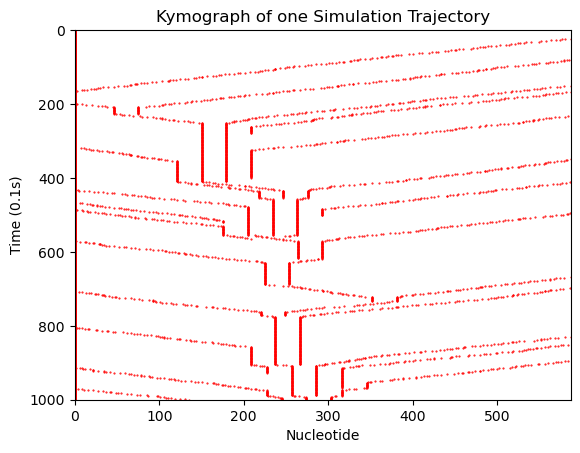

In [3]:

model = rsnp.tasep_model(mRNA, 'tsixxist') # model object

## overwite the default kelongation matrix 
kelong_mat = np.zeros([3, mRNA_length])
kelong_mat[0, :-1] = 4 
kelong_mat[1, :-1] = 4
kelong_mat[2, :-1] = 4
kelong_mat[0, -1] = 0 # cant step out of 0 frame
kelong_mat[1,0] = 0 # cant step out of 1 frame
kelong_mat[1,-1] = 4 # cant step out of 1 frame


model._kelong_mat = kelong_mat #override the current kelongation mat
model._probe_mat = np.zeros([3, mRNA_length])

footprint = 30
model.particle_size = 30
last_codon = mRNA_length-1

initiation_tsix = .08
initiation_xist = .08

termination_tsix = 10
termination_xist = 10

dropoff_tsix = .01
dropoff_xist = .01 

# histone bursting
k_xoff = .5
k_xon = .5
k_toff = .5
k_ton = .5

# labelling reactions, labeling the particles
klabel = 10000

parameters = [initiation_xist, initiation_tsix, k_xoff, k_xon, k_toff, k_ton, klabel, termination_tsix, termination_xist, dropoff_tsix, dropoff_xist]
# k is the parameters, t = timepoint, p = ribosome_array/array, occupation array, lattice array, probe matrix, state matrix
# r = resources, nr = number of ribosomes
# Check the docstring!

# Initiation rate of XIST going forwards
init_xist = lambda k,t,p,ke,o,l,pr,s,r,nr: (1-np.any(l[0:0+footprint]))*k[0]*s[0]
model.add_lattice_reaction(init_xist, parameters, rxn_name = 'initiation_xist', frame=0, loc=0, dexist=1,)

# Intiation rate of TSIX going backwards
init_tsix = lambda k,t,p,ke,o,l,pr,s,r,nr: (1-np.any(l[last_codon-footprint:last_codon+1]))*k[1]*s[1]
model.add_lattice_reaction(init_tsix, parameters, rxn_name = 'initiation_tsix', frame=1, loc=last_codon, dexist=1,)

# Termination rate of XIST going forwards
term_xist = lambda k,t,p,ke,o,l,pr,s,r,nr: k[7]*l[last_codon]
model.add_lattice_reaction(term_xist, parameters, rxn_name = 'term_xist', frame=0, loc=last_codon, dexist=-1,)

# Termination rate of TSIX going backwards
term_tsix = lambda k,t,p,ke,o,l,pr,s,r,nr: k[8]*l[0]
model.add_lattice_reaction(term_tsix, parameters, rxn_name = 'term_tsix', frame=1, loc=0, dexist=-1,)


model.add_states(2, state0=[0,0], names=['xist_histone','tsix_histone'])
####### HISTONES ###########
# state = [xist on, tsix on]
# histone turning off at Xist
histone_xist_off = lambda k,t,p,ke,o,l,pr,s,r,nr: (s[0]==1)*k[2]
model.add_state_reaction(histone_xist_off, parameters, rxn_name = 'histone_xist_off', inds=[0], dstates=[-1])

histone_xist_on = lambda k,t,p,ke,o,l,pr,s,r,nr: (s[0]==0)*k[3]
model.add_state_reaction(histone_xist_on, parameters, rxn_name = 'histone_xist_on', inds=[0], dstates=[1])

# state = [xist on, tsix on]
# histone turning off at tsix
histone_tsix_off = lambda k,t,p,ke,o,l,pr,s,r,nr: (s[1]==1)*k[4]
model.add_state_reaction(histone_tsix_off, parameters, rxn_name = 'histone_xist_off', inds=[1], dstates=[-1])

histone_tsix_on = lambda k,t,p,ke,o,l,pr,s,r,nr: (s[1]==0)*k[5]
model.add_state_reaction(histone_tsix_on, parameters, rxn_name = 'histone_xist_on', inds=[1], dstates=[1])


# SAME RATE WORKS BOTH WAYS FOR DNA SINCE NUCLEOTIDES ARE ADDED ONE AT A TIME
                                                # agent frame, agent location
step_forward = lambda k,t,p,ke,o,l,pr,s,r,nr: [ (p[i,2] == 0)*(ke[p[i,2], p[i,3]])*(1 - sum(l[p[i,3]+1:p[i,3]+footprint])) for i in range(nr)]
model.add_ribosome_reaction(step_forward, parameters, rxn_name='step forwards', exclusion=1, dloc=1) 

step_backwards = lambda k,t,p,ke,o,l,pr,s,r,nr: [ (p[i,2] == 1)*(ke[p[i,2], p[i,3]])*(1 - sum(l[p[i,3]-footprint:p[i,3]-1])) for i in range(nr)]
model.add_ribosome_reaction(step_backwards, parameters, rxn_name='step backwards', exclusion=1, dloc=-1) 

drop_off_forwards = lambda k,t,p,ke,o,l,pr,s,r,nr: [ (p[i,2] == 0)*(l[p[i,3]+1:p[i,3]+footprint+3].any())*k[9] for i in range(nr)]
model.add_ribosome_reaction(drop_off_forwards, parameters, rxn_name='drop forwards', exclusion=1, dexist=-1) 

drop_off_backwards = lambda k,t,p,ke,o,l,pr,s,r,nr: [ (p[i,2] == 1)*(l[p[i,3]-footprint:p[i,3]-3].any())*k[10] for i in range(nr)]
model.add_ribosome_reaction(drop_off_backwards, parameters, rxn_name='drop backwards', exclusion=1, dexist=-1) 


# finally specify which reactions are ribosome specific, this should be automated in the future
model._ribosome_reactions = [8,9,10,11]
model._constant_reactions = [0,1,2,3,4,5,6,7]
model._lattice_arr0 = np.zeros([model._length], dtype=int)
model._state_arr0 = np.array([0,0],dtype=int) # states are always going to start OFF, must burn this in!
